<a href="https://colab.research.google.com/github/HarirajS29/naivebayes/blob/main/DL_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
105/105 - 3s - 29ms/step - loss: 0.0143 - val_loss: 0.0219
Epoch 2/50
105/105 - 1s - 9ms/step - loss: 0.0086 - val_loss: 0.0212
Epoch 3/50
105/105 - 1s - 7ms/step - loss: 0.0072 - val_loss: 0.0241
Epoch 4/50
105/105 - 1s - 5ms/step - loss: 0.0067 - val_loss: 0.0203
Epoch 5/50
105/105 - 1s - 6ms/step - loss: 0.0065 - val_loss: 0.0287
Epoch 6/50
105/105 - 1s - 5ms/step - loss: 0.0070 - val_loss: 0.0191
Epoch 7/50
105/105 - 1s - 6ms/step - loss: 0.0059 - val_loss: 0.0184
Epoch 8/50
105/105 - 1s - 5ms/step - loss: 0.0051 - val_loss: 0.0199
Epoch 9/50
105/105 - 1s - 7ms/step - loss: 0.0059 - val_loss: 0.0154
Epoch 10/50
105/105 - 1s - 5ms/step - loss: 0.0056 - val_loss: 0.0145
Epoch 11/50
105/105 - 1s - 5ms/step - loss: 0.0049 - val_loss: 0.0149
Epoch 12/50
105/105 - 1s - 7ms/step - loss: 0.0049 - val_loss: 0.0096
Epoch 13/50
105/105 - 1s - 5ms/step - loss: 0.0042 - val_loss: 0.0073
Epoch 14/50
105/105 - 1s - 8ms/step - loss: 0.0036 - val_loss: 0.0039
Epoch 15/50
105/105 - 1s - 8

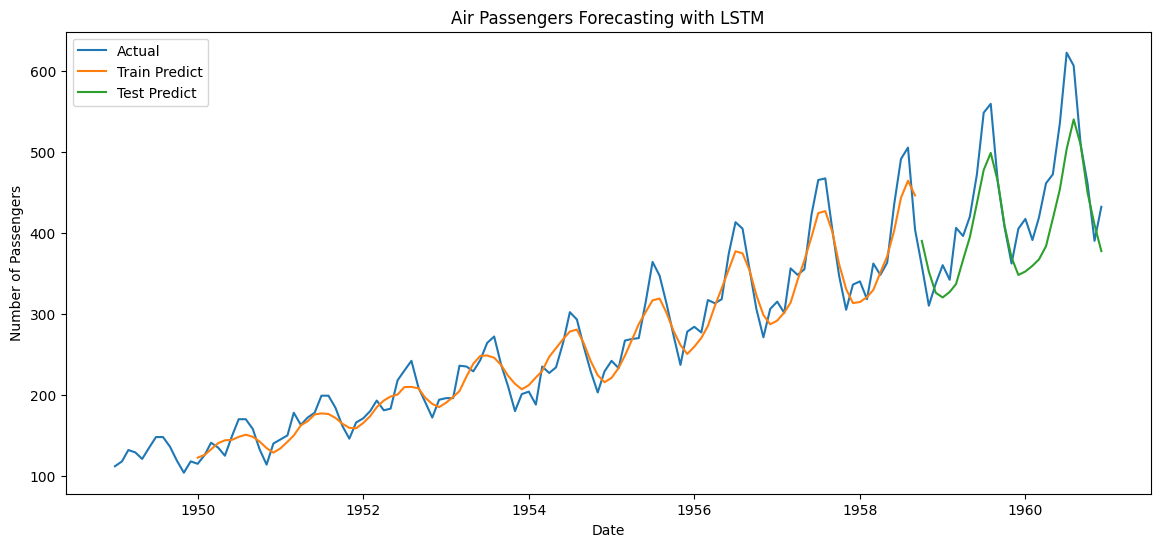

Actual passengers for 1960-12: 432
Predicted passengers for 1960-12: 377
Test set prediction accuracy (MAPE): 90.77%


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load dataset
data = pd.read_csv('/content/AirPassengers (1).csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

# Prepare data
dataset = data['#Passengers'].values.astype('float32').reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

# Create sequences
def create_dataset(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 12
X, y = create_dataset(dataset_scaled, look_back)

# Train/test split (last 20% for test)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape input to [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], look_back, 1))
X_test = X_test.reshape((X_test.shape[0], look_back, 1))

# Build LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(look_back, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=1, verbose=2, validation_data=(X_test, y_test))

# Predict
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invert scaling
train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Prepare for plotting
train_predict_plot = np.empty_like(dataset)
train_predict_plot[:, :] = np.nan
train_predict_plot[look_back:look_back+len(train_predict), :] = train_predict

test_predict_plot = np.empty_like(dataset)
test_predict_plot[:, :] = np.nan
test_predict_plot[look_back+len(train_predict):, :] = test_predict

# Plot actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(data.index, dataset, label='Actual')
plt.plot(data.index, train_predict_plot, label='Train Predict')
plt.plot(data.index, test_predict_plot, label='Test Predict')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title('Air Passengers Forecasting with LSTM')
plt.legend()
plt.show()

# Print last actual and predicted value for 1960-12
print(f"Actual passengers for 1960-12: {int(dataset[-1][0])}")
print(f"Predicted passengers for 1960-12: {int(test_predict[-1][0])}")

# Calculate and print test set MAPE
mape = np.mean(np.abs((y_test_inv - test_predict) / y_test_inv)) * 100
print(f"Test set prediction accuracy (MAPE): {100 - mape:.2f}%")